# 一、神经网络

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# PyTorch 深度学习框架
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# 自动选择设备（有GPU用GPU，无GPU用CPU）
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前运行设备: {device}")

当前运行设备: cpu


## 1.多层感知机
下述模型利用 PyTorch 搭建多层感知机 MLP，在 MNIST 手写数字数据集上实现 0-9 数字多分类。对原始图像进行标准化预处理，构建由两层隐藏层组成的全连接网络；采用交叉熵损失函数、Adam 优化器执行前向传播、反向传播迭代训练。记录每一轮训练损失与训练集准确率，并绘制训练曲线，观察模型收敛过程。

Epoch 1/5 | 损失: 0.2298 | 准确率: 93.01%
Epoch 2/5 | 损失: 0.0958 | 准确率: 97.04%
Epoch 3/5 | 损失: 0.0668 | 准确率: 97.85%
Epoch 4/5 | 损失: 0.0490 | 准确率: 98.39%
Epoch 5/5 | 损失: 0.0412 | 准确率: 98.65%


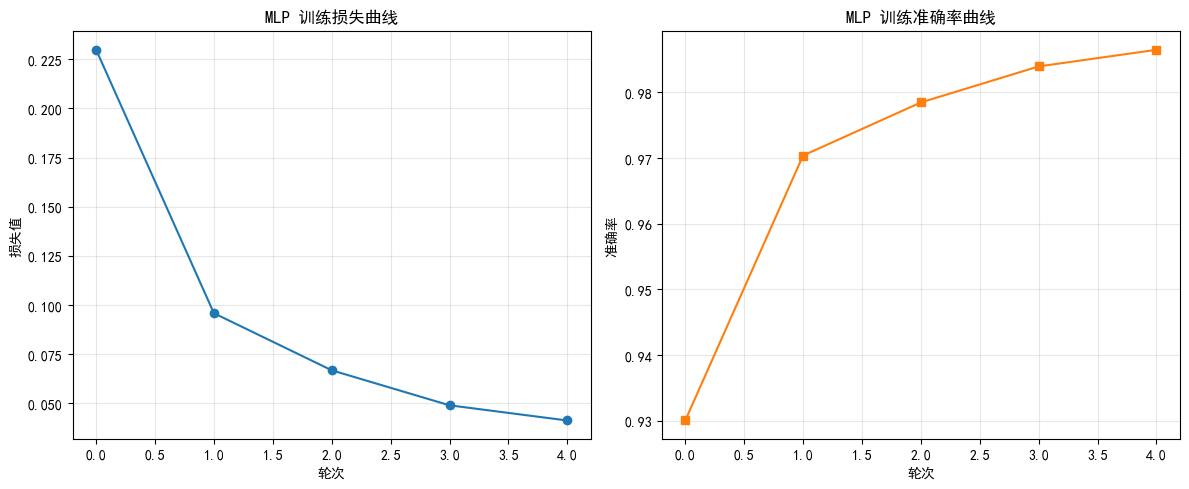

In [7]:
# 1. 数据准备：MNIST 手写数字数据集 
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 官方均值与标准差
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# 2. 模型定义 
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),          # 将 28×28 二维图片展平为 784 维向量
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),             
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, num_classes)  # 输出10个类别的得分
        )
    
    def forward(self, x):
        return self.net(x)

mlp = MLP().to(device)
criterion = nn.CrossEntropyLoss()      
optimizer = optim.Adam(mlp.parameters(), lr=0.001)

# 3. 训练函数
def train_classifier(model, train_loader, criterion, optimizer, epochs=5):
    train_loss = []
    train_acc = []
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()          # 梯度清零
            outputs = model(imgs)          # 前向传播
            loss = criterion(outputs, labels)  # 计算损失
            loss.backward()                # 反向传播
            optimizer.step()               # 更新参数
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        avg_loss = total_loss / len(train_loader)
        acc = correct / total
        train_loss.append(avg_loss)
        train_acc.append(acc)
        print(f"Epoch {epoch+1}/{epochs} | 损失: {avg_loss:.4f} | 准确率: {acc:.2%}")
    
    return train_loss, train_acc

# 开始训练
mlp_loss, mlp_acc = train_classifier(mlp, train_loader, criterion, optimizer, epochs=5)

# 4. 可视化训练曲线 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(mlp_loss, 'o-', color='#1f77b4')
plt.xlabel('轮次')
plt.ylabel('损失值')
plt.title('MLP 训练损失曲线')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mlp_acc, 's-', color='#ff7f0e')
plt.xlabel('轮次')
plt.ylabel('准确率')
plt.title('MLP 训练准确率曲线')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.卷积神经网络
下述模型利用 PyTorch 搭建卷积神经网络 CNN 完成 MNIST 手写数字识别任务。对图像进行张量转换与标准化预处理，网络通过卷积层、池化层自动提取图像空间特征，再经由全连接层实现分类。使用交叉熵损失与 Adam 优化器进行迭代训练，记录每轮训练损失与准确率，并绘制训练曲线，观察模型收敛过程。

Epoch 1/5 | 损失: 0.1509 | 准确率: 95.36%
Epoch 2/5 | 损失: 0.0484 | 准确率: 98.48%
Epoch 3/5 | 损失: 0.0313 | 准确率: 99.00%
Epoch 4/5 | 损失: 0.0229 | 准确率: 99.28%
Epoch 5/5 | 损失: 0.0180 | 准确率: 99.41%


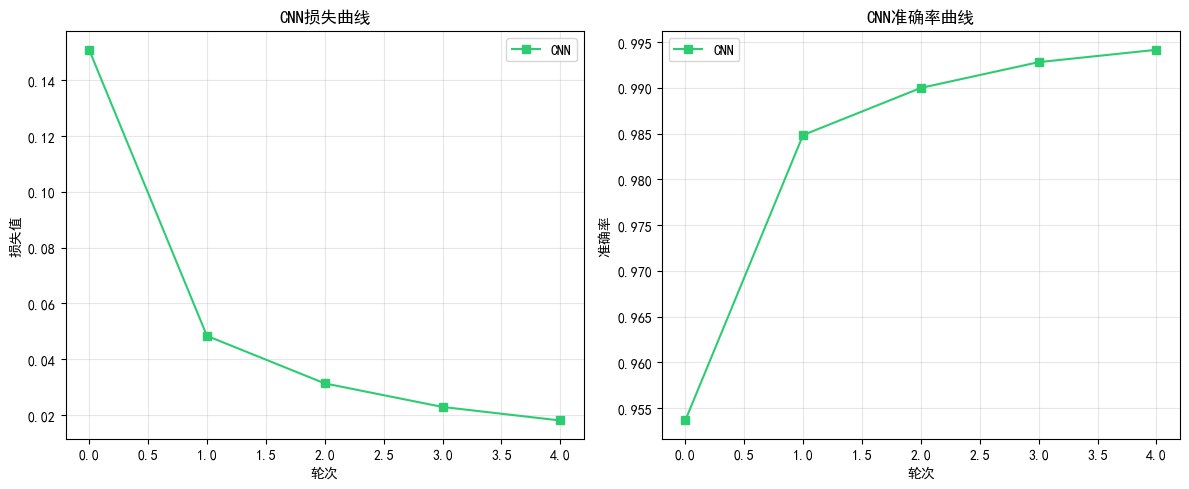

In [8]:
# 1.数据集加载（MNIST）
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 2.训练函数 
def train_classifier(model, train_loader, criterion, optimizer, epochs=5):
    train_loss = []
    train_acc = []
    model.train()
    
    for epoch in range(epochs):
        total_loss = 0
        correct = 0
        total = 0
        
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        avg_loss = total_loss / len(train_loader)
        acc = correct / total
        train_loss.append(avg_loss)
        train_acc.append(acc)
        print(f"Epoch {epoch+1}/{epochs} | 损失: {avg_loss:.4f} | 准确率: {acc:.2%}")
    
    return train_loss, train_acc

# 3.CNN模型定义 
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# 4.初始化CNN
cnn = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=0.001)

# 5.训练CNN
cnn_loss, cnn_acc = train_classifier(cnn, train_loader, criterion, optimizer, epochs=5)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_loss, 's-', label='CNN', color='#2ecc71')
plt.xlabel('轮次')
plt.ylabel('损失值')
plt.title('CNN损失曲线')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(cnn_acc, 's-', label='CNN', color='#2ecc71')
plt.xlabel('轮次')
plt.ylabel('准确率')
plt.title('CNN准确率曲线')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3.循环神经网络
RNN 专门处理时序序列数据，通过隐藏状态在时间步之间传递信息，捕捉序列依赖关系。<br/>
下述模型利用 LSTM 长短期记忆网络实现正弦时间序列单步预测。生成正弦模拟时序数据，构造 “利用前 20 个时刻数值预测下一时刻数值” 的监督学习样本；搭建 LSTM 网络捕捉序列前后依赖关系，采用均方误差作为损失函数、Adam 优化器迭代训练。记录训练损失变化，并在测试集对比真实值与预测值，直观验证 LSTM 对周期性时序数据的建模与预测能力。

Epoch 20/100 | MSE损失: 0.439432
Epoch 40/100 | MSE损失: 0.219587
Epoch 60/100 | MSE损失: 0.088675
Epoch 80/100 | MSE损失: 0.038646
Epoch 100/100 | MSE损失: 0.007835


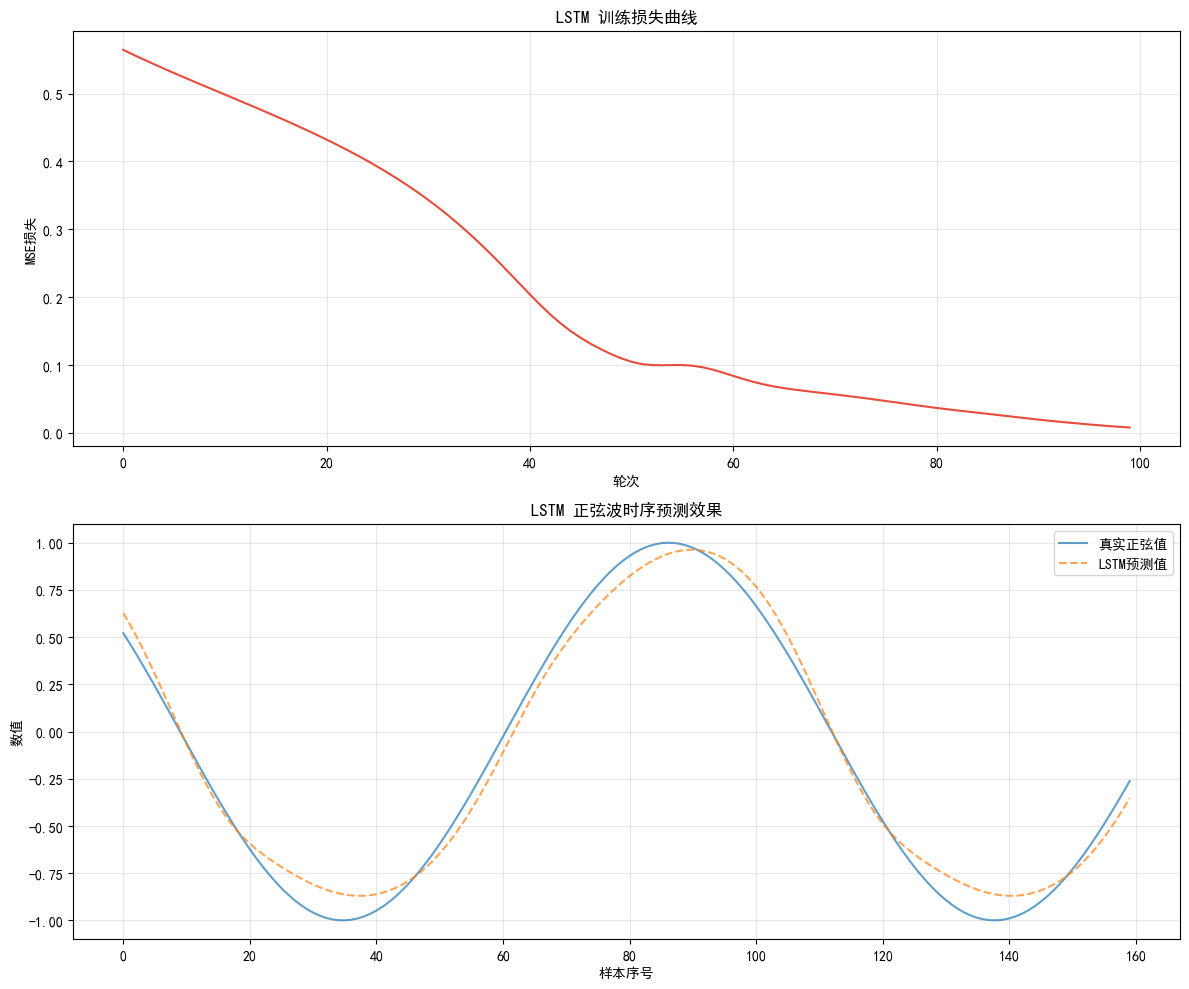

In [9]:
# 1.生成正弦波时序数据 
def generate_sine_data(seq_len=20, num_samples=800):
    x = np.linspace(0, 50, num_samples + seq_len)
    y = np.sin(x)
    data = []
    for i in range(num_samples):
        data.append(y[i:i+seq_len+1]) 
    data = np.array(data, dtype=np.float32)
    return data[:, :-1], data[:, -1]

seq_len = 20
X, y = generate_sine_data(seq_len=seq_len)
X = torch.tensor(X).unsqueeze(-1)  # [样本数, 序列长度, 特征数]
y = torch.tensor(y).unsqueeze(-1)

# 划分训练集和测试集
split = int(0.8 * len(X))
X_train, X_test = X[:split].to(device), X[split:].to(device)
y_train, y_test = y[:split].to(device), y[split:].to(device)

# 2. LSTM 模型定义 
class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x: [batch, seq_len, input_size]
        out, (h_n, c_n) = self.lstm(x)
        last_out = out[:, -1, :]  # 取最后一个时间步的输出
        pred = self.fc(last_out)
        return pred

lstm_model = LSTMPredictor().to(device)
criterion = nn.MSELoss()  
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

# 3. 训练 
epochs = 100
loss_history = []
for epoch in range(epochs):
    optimizer.zero_grad()
    pred = lstm_model(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())
    
    if (epoch+1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | MSE损失: {loss.item():.6f}")

# 4. 可视化结果
lstm_model.eval()
with torch.no_grad():
    test_pred = lstm_model(X_test).cpu().numpy()

plt.figure(figsize=(12, 10))

plt.subplot(2, 1, 1)
plt.plot(loss_history, color='#e74c3c')
plt.xlabel('轮次')
plt.ylabel('MSE损失')
plt.title('LSTM 训练损失曲线')
plt.grid(alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(y_test.cpu().numpy(), label='真实正弦值', alpha=0.7)
plt.plot(test_pred, label='LSTM预测值', alpha=0.7, linestyle='--')
plt.xlabel('样本序号')
plt.ylabel('数值')
plt.title('LSTM 正弦波时序预测效果')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()